# ***Первичный анализ музыкальных данных***

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Гугл диск успешно подключен

In [9]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/spotify_artist_streaming_2020_2025.csv')

Файл читаем в DataFrame с именем df

### ***Задание 2. Первичное знакомство с датасетом***

In [10]:
df

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,...,popularity_category,loudness_category,key_name,mode_name,is_explicit_bool,release_quarter,is_weekend_release,log_stream_count,upbeat_score,artist_track_count
0,346d85e2-ffde-41b3-854a-589ed880b91f,Storm,Ethereal,The Hollow Journeys,2021-10-06,Pop,169594,47,0.6777,0.7949,...,Medium,Loud,A,Major,False,Q4,False,10.7492,0.6632,3232
1,12bc268a-363b-4f19-8fa8-0ced7ae1e462,Silent,The Wolfs,Ancient Thunder,2024-10-26,K-Pop,256755,26,0.9405,0.7163,...,Medium,Moderate,C#,Major,False,Q4,True,8.5895,0.7615,20
2,30d627d9-878d-4bb3-be59-71feb6ed4f3f,Shattered Lines,LolaOre,Twisted Harbors,2022-11-12,Punk,170212,46,0.6853,0.9500,...,Medium,Loud,E,Major,False,Q4,True,12.2935,0.7828,199
3,85501bb9-d221-4339-9e2e-29b1b3daff0a,Breaking Roses,Clay Black,The Blinding Letters,2020-06-22,Pop,181250,4,0.7817,0.6943,...,Low,Moderate,F#,Major,False,Q2,False,8.5658,0.6778,693
4,7bf92bd2-c6fe-4869-a90e-242bb8bbe7a3,Lines,Knot Hart,The Cosmic Letters,2024-01-22,Latin,160894,27,0.7200,0.4958,...,Medium,Moderate,C#,Major,False,Q1,False,10.2191,0.5494,12111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,38913908-e3ab-42a2-9a97-2d1847c21e3b,Flames,Luna Ink,The Shattered Tapes,2025-02-27,Hip-Hop,249380,6,0.7338,0.8172,...,Low,Loud,C#,Major,False,Q1,False,6.2005,0.7545,577
49996,83653402-ca85-4583-b7ec-13ab3e82888e,Love,Knot Hart,Young II,2021-07-25,Folk,176329,22,0.5547,0.0000,...,Low,Quiet,A#,Minor,True,Q3,True,9.1916,0.3292,12111
49997,4398dd33-ecfc-4c1a-ab9e-248f38082318,The Waves,Jasper Jade,The Burning Journeys,2023-12-24,Pop,202472,5,0.6558,0.8805,...,Low,Moderate,G,Major,True,Q4,True,7.8200,0.6794,181
49998,07c673e7-39a5-4c28-8789-163ae5f17f3f,Flying Eyes,ElaraRain,Frequencies,2020-08-17,Rock,172542,81,0.5979,0.6252,...,Very High,Moderate,F#,Minor,False,Q3,False,15.1911,0.5622,1111


Команда df вывела весь датасет

In [11]:
df.head(10)

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,...,popularity_category,loudness_category,key_name,mode_name,is_explicit_bool,release_quarter,is_weekend_release,log_stream_count,upbeat_score,artist_track_count
0,346d85e2-ffde-41b3-854a-589ed880b91f,Storm,Ethereal,The Hollow Journeys,2021-10-06,Pop,169594,47,0.6777,0.7949,...,Medium,Loud,A,Major,False,Q4,False,10.7492,0.6632,3232
1,12bc268a-363b-4f19-8fa8-0ced7ae1e462,Silent,The Wolfs,Ancient Thunder,2024-10-26,K-Pop,256755,26,0.9405,0.7163,...,Medium,Moderate,C#,Major,False,Q4,True,8.5895,0.7615,20
2,30d627d9-878d-4bb3-be59-71feb6ed4f3f,Shattered Lines,LolaOre,Twisted Harbors,2022-11-12,Punk,170212,46,0.6853,0.9500,...,Medium,Loud,E,Major,False,Q4,True,12.2935,0.7828,199
3,85501bb9-d221-4339-9e2e-29b1b3daff0a,Breaking Roses,Clay Black,The Blinding Letters,2020-06-22,Pop,181250,4,0.7817,0.6943,...,Low,Moderate,F#,Major,False,Q2,False,8.5658,0.6778,693
4,7bf92bd2-c6fe-4869-a90e-242bb8bbe7a3,Lines,Knot Hart,The Cosmic Letters,2024-01-22,Latin,160894,27,0.7200,0.4958,...,Medium,Moderate,C#,Major,False,Q1,False,10.2191,0.5494,12111
5,e4a536ca-c6d4-4bad-97b5-d5e7b85c49e2,Wild Doors,Knot Hart,Jagged Gardens,2021-04-12,R&B,198179,28,0.6538,0.3732,...,Medium,Moderate,G#,Major,False,Q2,False,9.8292,0.4586,12111
6,305b4f13-b2ac-47e9-a6f2-d0c15934f8b6,Skies,Knot Hart,The Ancient Tapes,2025-07-16,R&B,251330,18,0.7399,0.4000,...,Low,Moderate,G,Minor,False,Q3,False,9.6072,0.5475,12111
7,83c3a6be-6066-449a-a339-19afcde7cfb3,Wild,Blaze Project,Crystal,2023-12-12,Classical,208198,15,0.1730,0.3085,...,Low,Moderate,G#,Major,True,Q4,False,6.9745,0.2482,53
8,437961fc-9ccd-4c86-8eb7-e96b6d2dc5c8,Neon Oceans,Clay Black,Broken V,2020-06-17,Pop,254751,23,0.6838,0.5026,...,Low,Moderate,G,Minor,True,Q2,False,8.3301,0.5249,693
9,53df0c89-adc4-48b7-94e3-111e348cb17b,Eternal Angels,Phantasm,The Kind Notes,2020-06-09,Trap,310076,39,0.5759,0.8349,...,Medium,Moderate,D#,Minor,False,Q2,False,12.1223,0.6488,242


Метод df.head(10) вывел первые 10 строк таблицы. Вывел:название треков, исполнителей, жанры, популярность, и тд.

In [12]:
df.shape

(50000, 33)

Определили количество строк и столбцов. Позволяет узнать общий размер датасет

In [13]:
df.columns

Index(['track_id', 'track_name', 'artist_name', 'album_name', 'release_date',
       'genre', 'duration_ms', 'popularity', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count',
       'country', 'explicit', 'label', 'release_year', 'release_month',
       'release_day_of_week', 'duration_minutes', 'popularity_category',
       'loudness_category', 'key_name', 'mode_name', 'is_explicit_bool',
       'release_quarter', 'is_weekend_release', 'log_stream_count',
       'upbeat_score', 'artist_track_count'],
      dtype='object')

Вывела названия всех столбцов.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             50000 non-null  object 
 1   track_name           50000 non-null  object 
 2   artist_name          50000 non-null  object 
 3   album_name           50000 non-null  object 
 4   release_date         50000 non-null  object 
 5   genre                50000 non-null  object 
 6   duration_ms          50000 non-null  int64  
 7   popularity           50000 non-null  int64  
 8   danceability         50000 non-null  float64
 9   energy               50000 non-null  float64
 10  key                  50000 non-null  int64  
 11  loudness             50000 non-null  float64
 12  mode                 50000 non-null  int64  
 13  instrumentalness     50000 non-null  float64
 14  tempo                50000 non-null  float64
 15  stream_count         50000 non-null 

df.info() показал кол-во заполненых значений. Пропусков 0

### ***Задание 3. Сортировка данных***

In [17]:
top10 = df.sort_values(by='stream_count', ascending=False).head(10)

top10[['track_name', 'artist_name', 'genre', 'stream_count', 'popularity']]

,track_name,artist_name,genre,stream_count,popularity
1528,The Roses,Grove Nova,Alternative,43345015,90
36998,Bitter,Flora Quinn,Rock,26635547,79
42813,The Streets,Ethereal,Pop,26314312,80
21643,Breaking Thunder,SethStone,Metal,20408155,70
49193,The Pages,IsleEyre,Pop,19265301,78
26622,Lights,Dean System,Hip-Hop,17238449,81
45015,Gentle,Rocco Ore,R&B,15776187,83
39012,Storm,Knot Hart,R&B,14545933,72
29091,Burning Islands,The Inks,Pop,14507867,82
13635,Broken Eyes,Prism Hart,R&B,14367106,92


Отсортировали датасет по убыванию и взяли первые 10 строк самых прослушенных треков.

**Какие исполнители и жанры встречаются среди самых прослушиваемых треков?**

Среди самых прослушиваемых треков встречаются исполнители: Grove Nova, Flora Quinn, Ethereal, SethStone, IsleEyre,Dean System, Rocco Ore, Knot Hart, The Inks, Prism Hart.
Популярные жанры : R&B и Pop.

### ***Задание 4. Фильтрация***

In [16]:
tracks_after_2024 = df[df['release_year'] > 2024]
tracks_after_2024[['track_name', 'artist_name', 'genre', 'release_year']].head(20)

,track_name,artist_name,genre,release_year
6,Skies,Knot Hart,R&B,2025
14,The Roads,Knot Hart,R&B,2025
17,Liquid Streets,ElaraRain,Pop,2025
18,Broken Ghosts,Sterling Zen,Hip-Hop,2025
24,The Tears,Sterling Zen,Folk,2025
27,Eternal,SethStone,Metal,2025
42,Waiting Night,Knot Hart,R&B,2025
46,Oceans,IsleEyre,Pop,2025
50,Empty Flames,Onyx Core,Pop,2025
60,Young Floors,Ethereal,Pop,2025


Отфильтровались строки, у которых release_year больше 2024. В датасете практически все треки за 2025 год

### ***Задание 4. Основные статистические показатели***

In [18]:
mean_pop = df['popularity'].mean()
median_pop = df['popularity'].median()

print(f"Среднее значение popularity: {mean_pop:.2f}")
print(f"Медиана popularity: {median_pop:.2f}")

Среднее значение popularity: 28.14
Медиана popularity: 26.00


Среднее и медиана близки, но медиана ниже, значит есть треки с очень высокой популярностью.

In [19]:
stats = df['popularity'].agg(['min', 'max', 'std'])
print(stats)

min     0.000000
max    92.000000
std    15.999501
Name: popularity, dtype: float64


Среднее (28.14) больше медианы (26.00), значит есть треки с высокой популярностью, которые тянут среднее вверх. Стандартное отклонение (+-16) показывает большой разброс значений от 0 до 92

### ***Задание 5. Мода***

In [21]:
# Мода для столбца genre
mode_genre = df['genre'].mode()
print("Мода для genre:")
print(mode_genre)


Мода для genre:
0    R&B
Name: genre, dtype: object


In [23]:
# Мода для столбца release_year
mode_year = df['release_year'].mode()
print("\nМода для release_year:")
print(mode_year)


Мода для release_year:
0    2024
Name: release_year, dtype: int64


Мода для жанра - R&B, для года выпуска — 2024, т.е эти значения встречаются в датасете чаще всего



### ***Задание 7. Гистограмма***

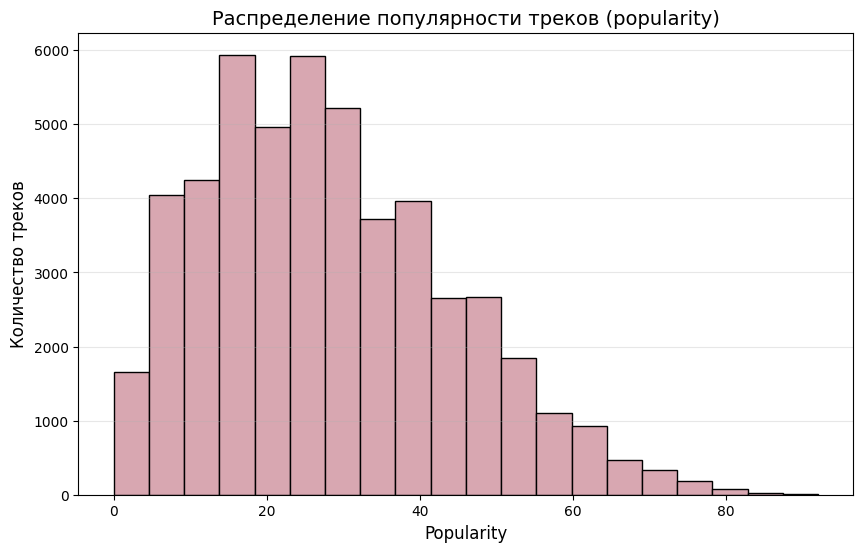

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=20, color='#D8A7B1', edgecolor='black')

plt.title('Распределение популярности треков (popularity)', fontsize=14)
plt.xlabel('Popularity', fontsize=12)
plt.ylabel('Количество треков', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

 Основная масса треков — в диапазоне 10–45, значения выше 60 редки.